In [1]:
!pip install anndata==0.8.0

In [2]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [3]:
def binary_exp(ct, gdict, marker_dict,org_g_dict, gene_ord):
    heatmap = pd.DataFrame(data = np.zeros((len(ct),len(gene_ord))),index = ct, columns = gene_ord)
    for item in ct:
        if item in marker_dict:
            for g in heatmap.columns:
                org_g = org_g_dict[g]
                if org_g in marker_dict[item]:
                    heatmap.loc[item,g] +=1
                if type(org_g) == float:
                    heatmap.loc[item,g] = np.nan
        else:
            heatmap.loc[item,:] = [np.nan for i in range(len(gene_ord))]
    return(heatmap)

In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [5]:
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'
parent_dict['NN_unknown'] = 'not hypo'

In [7]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_6species_ohnlogs_expressionthresh_08022026.tsv',delimiter='\t', index_col = 'MM')

In [8]:
with open('../../Important_genes/MO_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/MO_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_mo = pickle.load(f)
    
with open('../../Important_genes/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/CJ_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_cj = pickle.load(f)
    
with open('../../Important_genes/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/AC_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_ac = pickle.load(f)
    
with open('../../Important_genes/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/XT_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_xt = pickle.load(f)
    
with open('../../Important_genes/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026/DR_cleaned_sssubclass_v4_or_hypobkgd_sigupdate_07272026.pkl', 'rb') as f:
    marker_dict_dr = pickle.load(f)
    
with open('../../Important_genes/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_mg = pickle.load(f)

In [9]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF_set = set(TF['0'])

In [10]:
overall_TF_set = set(otohomo.index) & TF_set

In [11]:
mg_exp ={i:i for i in overall_TF_set}
mo_exp = {i:otohomo.loc[i,'MO'] for i in overall_TF_set}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in overall_TF_set}
ac_exp = {i:otohomo.loc[i,'AC'] for i in overall_TF_set}
xt_exp = {i:otohomo.loc[i,'XT'] for i in overall_TF_set}
dr_exp = {i:otohomo.loc[i,'DR'] for i in overall_TF_set}

In [12]:
hypo_names = [i for i in marker_dict_mg.keys() if parent_dict[parent_dict[i]] == 'hypo']
hypo_names.sort()

In [13]:
fixed_gene_ord = list(mg_exp.keys())
bi_mg = binary_exp(hypo_names,mg_exp,marker_dict_mg,mg_exp,fixed_gene_ord)
bi_mo = binary_exp(hypo_names,mg_exp,marker_dict_mo,mo_exp,fixed_gene_ord)
bi_cj = binary_exp(hypo_names,mg_exp,marker_dict_cj,cj_exp,fixed_gene_ord)
bi_ac = binary_exp(hypo_names,mg_exp,marker_dict_ac,ac_exp,fixed_gene_ord)
bi_xt = binary_exp(hypo_names,mg_exp,marker_dict_xt,xt_exp,fixed_gene_ord)
bi_dr = binary_exp(hypo_names,mg_exp,marker_dict_dr,dr_exp,fixed_gene_ord)

In [14]:
np.sort(bi_mg.loc[:,'Dlx6'])

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.])

In [15]:
bi_cj.shape

(73, 616)

In [16]:
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgray")  # color for NaNs

<AxesSubplot:>

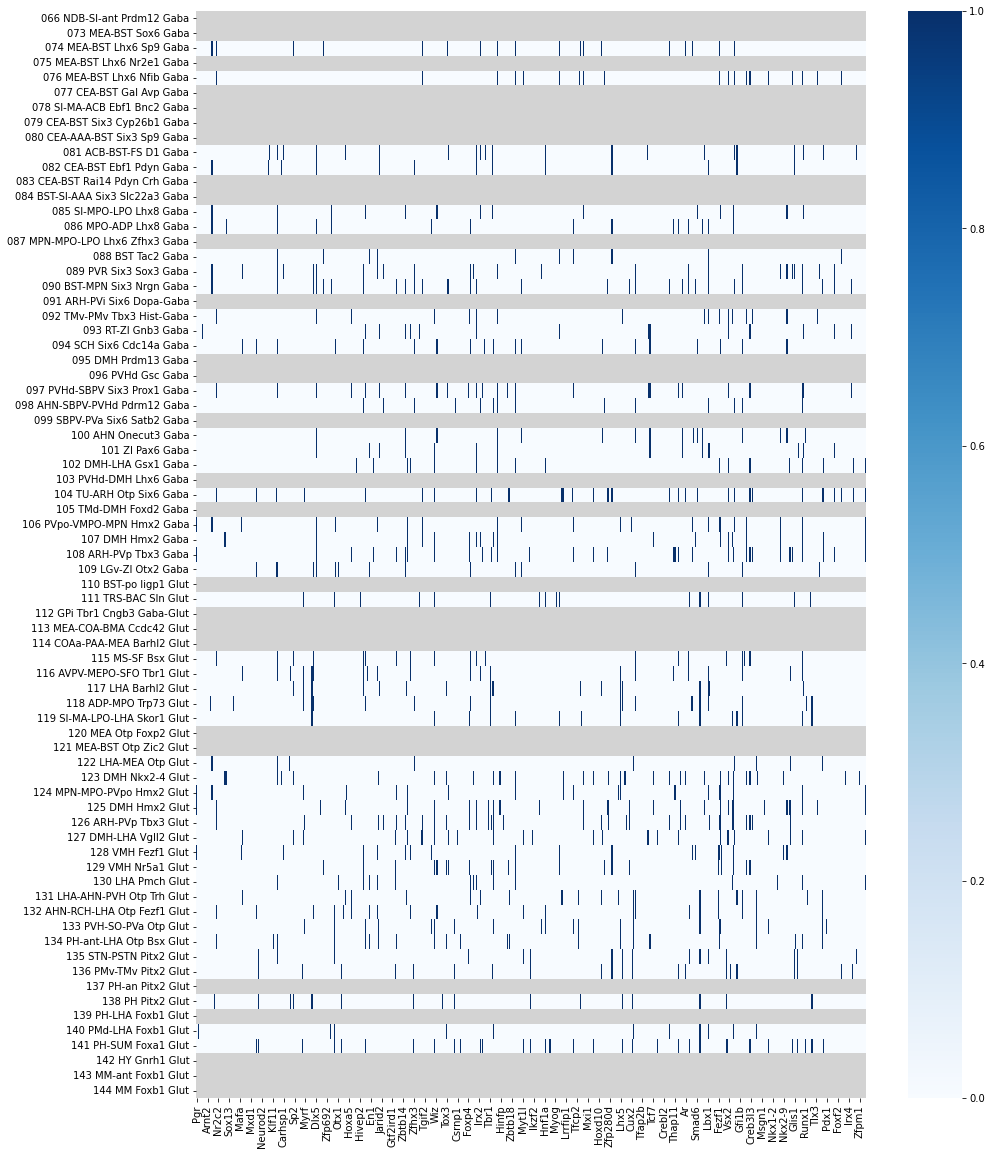

In [17]:
plt.figure(figsize=(15,20))
sns.heatmap(bi_cj, cmap = cmap,  linewidth=0.001, linecolor='black',)

In [18]:
fbi_mg = bi_mg.fillna(0)
fbi_mo = bi_mo.fillna(0)
fbi_cj = bi_cj.fillna(0)
fbi_ac = bi_ac.fillna(0)
fbi_xt = bi_xt.fillna(0)
fbi_dr = bi_dr.fillna(0)

In [19]:
fbi = fbi_mg + fbi_mo + fbi_cj + fbi_ac + fbi_xt + fbi_dr

In [20]:
num_orgs = pd.DataFrame(data = np.zeros((len(fbi.index),1)),columns = ['Num orgs'], index = fbi.index)
for item in num_orgs.index:
    if item in marker_dict_mg.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_mo.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_cj.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_ac.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_xt.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_dr.keys():
        num_orgs.loc[item,'Num orgs'] +=1

In [21]:
cts = num_orgs[num_orgs['Num orgs'] >= 4].index

In [22]:
fbi_all = fbi.loc[cts,:]

In [23]:
fin_index = fbi.columns[(fbi >= 4).any(axis=0)]

In [24]:
fin_index

Index(['Esrrg', 'Sp9', 'Foxg1', 'Tead1', 'Foxb1', 'Nfix', 'Pitx2', 'Zfp521',
       'Zic3', 'Onecut2',
       ...
       'Lhx2', 'Nfia', 'Foxa1', 'Pax6', 'Sox5', 'Meis1', 'Otp', 'Six3', 'Irx5',
       'Hmx3'],
      dtype='object', length=108)

In [25]:
fbi_all.shape

(48, 616)

In [26]:
fbi_all.loc[:,'Pgr']

073 MEA-BST Sox6 Gaba             0.0
074 MEA-BST Lhx6 Sp9 Gaba         0.0
076 MEA-BST Lhx6 Nfib Gaba        1.0
079 CEA-BST Six3 Cyp26b1 Gaba     0.0
082 CEA-BST Ebf1 Pdyn Gaba        0.0
085 SI-MPO-LPO Lhx8 Gaba          0.0
086 MPO-ADP Lhx8 Gaba             0.0
088 BST Tac2 Gaba                 0.0
089 PVR Six3 Sox3 Gaba            0.0
090 BST-MPN Six3 Nrgn Gaba        1.0
091 ARH-PVi Six6 Dopa-Gaba        1.0
092 TMv-PMv Tbx3 Hist-Gaba        0.0
093 RT-ZI Gnb3 Gaba               0.0
094 SCH Six6 Cdc14a Gaba          1.0
097 PVHd-SBPV Six3 Prox1 Gaba     0.0
098 AHN-SBPV-PVHd Pdrm12 Gaba     0.0
100 AHN Onecut3 Gaba              0.0
101 ZI Pax6 Gaba                  0.0
102 DMH-LHA Gsx1 Gaba             1.0
104 TU-ARH Otp Six6 Gaba          0.0
105 TMd-DMH Foxd2 Gaba            0.0
106 PVpo-VMPO-MPN Hmx2 Gaba       3.0
107 DMH Hmx2 Gaba                 0.0
108 ARH-PVp Tbx3 Gaba             1.0
111 TRS-BAC Sln Glut              0.0
115 MS-SF Bsx Glut                0.0
116 AVPV-MEP

In [27]:
genes = ['Foxa1', 'Irx5', 'Lmx1a', 'Lmx1b', 'Pitx2','Uncx','Lhx5','Sim1','Otp','Dlx1', 'Dlx2', 'Dlx5', 'Isl1',
         'Nfix','Tcf4','Neurod6','Zic1','Zic4','Prdm16','Lhx9','Lhx2','Rfx4','Pgr','Ar','Esr1']

In [28]:
fin_index

Index(['Esrrg', 'Sp9', 'Foxg1', 'Tead1', 'Foxb1', 'Nfix', 'Pitx2', 'Zfp521',
       'Zic3', 'Onecut2',
       ...
       'Lhx2', 'Nfia', 'Foxa1', 'Pax6', 'Sox5', 'Meis1', 'Otp', 'Six3', 'Irx5',
       'Hmx3'],
      dtype='object', length=108)

In [36]:
order = ['Dlx6','Dlx1','Dlx2','Dlx5','Isl1',
         'Foxa1', 'Irx5', 'Lmx1a', 'Lmx1b', 'Pitx2',
         'Barhl1','Barhl2','Irx3','Irx6',
         'Uncx','Lhx5','Sim1','Otp','Pou3f2','Sim2','Ebf3','Ebf2','Ebf1','Nfix','Nfia','Tcf4','Neurod6',
         'Zic1','Zic4','Prdm16','Zic3','Zic5','Lhx9','Lhx2','Rfx4','Pgr','Ar','Esr1','Tcf7l2','Rorb','Lef1', 'Sox2',  'Hmx2', 
         'Nr2f1','Sox6','Bcl11a','Tead1','Rora','Meis2','Mef2c','Six3',
         'Bsx', 'Tbx3','Dach1','Zfpm2','Nr5a2','Esr2','Pou6f2', 'Sp9','Bcl11b','Zfhx4','Arx', 'Sox5', 'Sp8', 'Vax1','Nr2f2','Hmx3','Gli3','Lhx8',
          'Prox1', 'St18', 'Prdm12','Nr4a2','Pbx3','Zeb2',
          'Zfhx3','Zfp521','Zfp536','Onecut2','Foxg1', 'Nkx2-1', 'Nr2e1',
       'Nr4a3','Gsc','Sall3', 'Eomes','Foxb1', 'Foxo1',
        'Emx2','Tbr1',  'Trp73', 'Pax6','Meis1', 'Sall1','Fezf1', 'Satb2','Glis3',
       'Fosl2',
       'Otx1',  'Casz1',  'Gbx2','Bnc2','Nkx2-2','Egr2', 'Esrrg', 'Prdm13', 'Six6', 'Zbtb16', 'Zic2']

In [37]:
from collections import Counter

counts = Counter(order)
repeats = {item: n for item, n in counts.items() if n > 1}

In [38]:
repeats

{}

In [39]:
set(fin_index) - set(order)

set()

In [40]:
set(order) - set(fin_index)

{'Pgr'}

In [41]:
len(order) == len(set(order))

True

In [42]:
fbi_all = fbi_all.loc[:,order]

In [43]:
fbi_all.columns

Index(['Dlx6', 'Dlx1', 'Dlx2', 'Dlx5', 'Isl1', 'Foxa1', 'Irx5', 'Lmx1a',
       'Lmx1b', 'Pitx2',
       ...
       'Casz1', 'Gbx2', 'Bnc2', 'Nkx2-2', 'Egr2', 'Esrrg', 'Prdm13', 'Six6',
       'Zbtb16', 'Zic2'],
      dtype='object', length=109)

In [44]:
mg_tf = []
mo_tf = []
cj_tf = []
ac_tf= []
xt_tf = []
dr_tf = []
for item in fbi_all.columns:
    mg_tf.append(mg_exp[item])
    mo_tf.append(mo_exp[item])
    cj_tf.append(cj_exp[item])
    ac_tf.append(ac_exp[item])
    xt_tf.append(xt_exp[item])
    dr_tf.append(dr_exp[item])

In [45]:
with open("../../mg_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mg_tf)  
    
with open("../../mo_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mo_tf)  
    
with open("../../cj_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cj_tf)  
    
with open("../../ac_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(ac_tf)  
    
with open("../../xt_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(xt_tf)  
    
with open("../../dr_tf_all_08032026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(dr_tf)  

In [46]:
JASPAR = pd.read_csv('../../JASPAR_TF_class_manuallylabeled.csv', index_col = 'Unnamed: 0')

In [47]:
c = []
for item in order:
    if item in JASPAR.index:
        c.append(JASPAR.loc[item, 'Class'].split(';')[0])
    elif item.upper() in JASPAR.index:
        c.append(JASPAR.loc[item.upper(), 'Class'].split(';')[0])
    else:
        print(item)
color_map = {'Paired box factors': '#ad1015',
 'Rel homology region (RHR) factors': '#79577C',
 'Fork head/winged helix factors': '#3C899E',
 'Nuclear receptors with C4 zinc fingers': '#49A75A',
 'C2H2 zinc finger factors': '#6F8273',
 'P53': '#9F5196',
 'MADS box factors': '#DF6F32',
 'Homeo domain factors': '#6e8541',
 'TEA domain factors': '#00c2f3',
 'Basic helix-loop-helix factors (bHLH)': '#CFA42D',
 'SMAD/NF-1 DNA-binding domain factors': '#B25C3F',
 'Basic leucine zipper factors (bZIP)': '#E4779C',
 'High-mobility group (HMG) domain factors': '#D28AB0',
 'T-Box factors': '#999999'}

In [48]:
fbi_all.index

Index(['073 MEA-BST Sox6 Gaba', '074 MEA-BST Lhx6 Sp9 Gaba',
       '076 MEA-BST Lhx6 Nfib Gaba', '079 CEA-BST Six3 Cyp26b1 Gaba',
       '082 CEA-BST Ebf1 Pdyn Gaba', '085 SI-MPO-LPO Lhx8 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '088 BST Tac2 Gaba', '089 PVR Six3 Sox3 Gaba',
       '090 BST-MPN Six3 Nrgn Gaba', '091 ARH-PVi Six6 Dopa-Gaba',
       '092 TMv-PMv Tbx3 Hist-Gaba', '093 RT-ZI Gnb3 Gaba',
       '094 SCH Six6 Cdc14a Gaba', '097 PVHd-SBPV Six3 Prox1 Gaba',
       '098 AHN-SBPV-PVHd Pdrm12 Gaba', '100 AHN Onecut3 Gaba',
       '101 ZI Pax6 Gaba', '102 DMH-LHA Gsx1 Gaba', '104 TU-ARH Otp Six6 Gaba',
       '105 TMd-DMH Foxd2 Gaba', '106 PVpo-VMPO-MPN Hmx2 Gaba',
       '107 DMH Hmx2 Gaba', '108 ARH-PVp Tbx3 Gaba', '111 TRS-BAC Sln Glut',
       '115 MS-SF Bsx Glut', '116 AVPV-MEPO-SFO Tbr1 Glut',
       '117 LHA Barhl2 Glut', '118 ADP-MPO Trp73 Glut',
       '119 SI-MA-LPO-LHA Skor1 Glut', '122 LHA-MEA Otp Glut',
       '123 DMH Nkx2-4 Glut', '124 MPN-MPO-PVpo Hmx2 Glut',
      

In [1]:
all_ct = ['073 MEA-BST Sox6 Gaba',
 '076 MEA-BST Lhx6 Nfib Gaba',
 '079 CEA-BST Six3 Cyp26b1 Gaba',
 '091 ARH-PVi Six6 Dopa-Gaba',
 '082 CEA-BST Ebf1 Pdyn Gaba',
 '088 BST Tac2 Gaba',
 '090 BST-MPN Six3 Nrgn Gaba',
 '102 DMH-LHA Gsx1 Gaba',
 '108 ARH-PVp Tbx3 Gaba','092 TMv-PMv Tbx3 Hist-Gaba', '107 DMH Hmx2 Gaba',
       '106 PVpo-VMPO-MPN Hmx2 Gaba','105 TMd-DMH Foxd2 Gaba', '101 ZI Pax6 Gaba',
       '097 PVHd-SBPV Six3 Prox1 Gaba', '093 RT-ZI Gnb3 Gaba',
       '100 AHN Onecut3 Gaba', '094 SCH Six6 Cdc14a Gaba',
       '074 MEA-BST Lhx6 Sp9 Gaba', '098 AHN-SBPV-PVHd Pdrm12 Gaba',
       '086 MPO-ADP Lhx8 Gaba', '089 PVR Six3 Sox3 Gaba','085 SI-MPO-LPO Lhx8 Gaba',
       '141 PH-SUM Foxa1 Glut', '136 PMv-TMv Pitx2 Glut',
       '135 STN-PSTN Pitx2 Glut',  '138 PH Pitx2 Glut',
'104 TU-ARH Otp Six6 Gaba',
       '134 PH-ant-LHA Otp Bsx Glut', '133 PVH-SO-PVa Otp Glut',
       '122 LHA-MEA Otp Glut', '132 AHN-RCH-LHA Otp Fezf1 Glut',
       '131 LHA-AHN-PVH Otp Trh Glut', '140 PMd-LHA Foxb1 Glut',
       '119 SI-MA-LPO-LHA Skor1 Glut', '111 TRS-BAC Sln Glut',
       '118 ADP-MPO Trp73 Glut', '123 DMH Nkx2-4 Glut',
 '124 MPN-MPO-PVpo Hmx2 Glut','116 AVPV-MEPO-SFO Tbr1 Glut',
 '117 LHA Barhl2 Glut',
       '126 ARH-PVp Tbx3 Glut', '115 MS-SF Bsx Glut', '129 VMH Nr5a1 Glut',
       '128 VMH Fezf1 Glut', '127 DMH-LHA Vgll2 Glut', '130 LHA Pmch Glut',
       '125 DMH Hmx2 Glut']

In [50]:
set(fbi_all.index) - set(all_ct)

set()

In [51]:
set(all_ct) - set(fbi_all.index)

set()

In [52]:
set(fbi_all.index) == set(all_ct)

True

In [53]:
fbi_all = fbi_all.reindex(all_ct)

In [54]:
b = []
for item in fbi_all.index:
    b.append(item.split(' ')[-1])
color_map_two = {'Glut':'#2b93df','Gaba':'#ff3358','Hist-Gaba':'#FF7621','Dopa-Gaba':'#FCF04B'}

In [55]:
color_map_two

{'Glut': '#2b93df',
 'Gaba': '#ff3358',
 'Hist-Gaba': 'Orange',
 'Dopa-Gaba': 'Yellow'}

In [56]:
TF_name_map = {'Basic helix-loop-helix factors (bHLH)':'Basic helix loop helix',
 'Basic leucine zipper factors (bZIP)':'Basic leucine zipper',
 'C2H2 zinc finger factors':'C2H2 zinc finger',
 'Fork head/winged helix factors':'Forkhead',
 'High-mobility group (HMG) domain factors':'High mobility group',
 'Homeo domain factors':'Homeodomain',
 'MADS box factors':'MADS box',
 'Nuclear receptors with C4 zinc fingers':'Nuclear receptor',
 'P53':'p53',
 'Paired box factors':'Paired box',
 'Rel homology region (RHR) factors':'Rel homology region',
 'SMAD/NF-1 DNA-binding domain factors':'SMAD/NF-1',
 'T-Box factors':'T-Box factor',
 'TEA domain factors':'TEA'}

In [57]:
TFfammap = {}
for item in order:
    if item in JASPAR.index:
        TFfammap[item] = TF_name_map[JASPAR.loc[item, 'Class'].split(';')[0]]
    elif item.upper() in JASPAR.index:
        TFfammap[item] = TF_name_map[JASPAR.loc[item.upper(), 'Class'].split(';')[0]]
    else:
        print(item)

In [58]:
TF

,Unnamed: 0,0
0,0,Hoxa6
1,1,Grhl3
2,2,Zhx3
3,3,Hivep3
4,4,Foxn1
...,...,...
1251,1251,Zfp827
1252,1252,Hivep1
1253,1253,Myog
1254,1254,Zfp69


In [59]:
TF_fam = pd.read_csv('../../Fin_TF_06012026.csv', index_col=0)
TF_fam['TF family'] = TF_fam['0'].map(TFfammap)
TF_fam.to_csv('../../Fin_TF_07282026.csv')

In [60]:
TF_fam[TF_fam['TF family'] == 'High mobility group']

,0,TF family
44,Sox2,High mobility group
181,Sox5,High mobility group
823,Lef1,High mobility group
1116,Sox6,High mobility group
1189,Tcf7l2,High mobility group


In [61]:
col_colors = pd.DataFrame({
    "TF class": pd.Series(c, index=fbi_all.columns).map(color_map)
})

In [62]:
len(col_colors.index)

109

In [63]:
len(col_colors[col_colors['TF class'] == '#FFA60F'])

0

In [64]:
f = []
for i in c:
    if i not in f:
        f.append(i)

In [65]:
f

['Homeo domain factors',
 'Fork head/winged helix factors',
 'C2H2 zinc finger factors',
 'Basic helix-loop-helix factors (bHLH)',
 'Rel homology region (RHR) factors',
 'SMAD/NF-1 DNA-binding domain factors',
 'Nuclear receptors with C4 zinc fingers',
 'High-mobility group (HMG) domain factors',
 'TEA domain factors',
 'MADS box factors',
 'T-Box factors',
 'P53',
 'Paired box factors',
 'Basic leucine zipper factors (bZIP)']

In [66]:
fbi_all

,Dlx6,Dlx1,Dlx2,Dlx5,Isl1,Foxa1,Irx5,Lmx1a,Lmx1b,Pitx2,...,Casz1,Gbx2,Bnc2,Nkx2-2,Egr2,Esrrg,Prdm13,Six6,Zbtb16,Zic2
073 MEA-BST Sox6 Gaba,1.0,3.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0
079 CEA-BST Six3 Cyp26b1 Gaba,2.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
091 ARH-PVi Six6 Dopa-Gaba,1.0,2.0,2.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0
082 CEA-BST Ebf1 Pdyn Gaba,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
088 BST Tac2 Gaba,1.0,3.0,3.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
090 BST-MPN Six3 Nrgn Gaba,2.0,1.0,1.0,3.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
102 DMH-LHA Gsx1 Gaba,1.0,4.0,2.0,2.0,4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
108 ARH-PVp Tbx3 Gaba,1.0,2.0,2.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0
092 TMv-PMv Tbx3 Hist-Gaba,1.0,3.0,2.0,3.0,5.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0


In [67]:
row_colors = pd.DataFrame({
    "Neurotransmitter": pd.Series(b, index=fbi_all.index).map(color_map_two)
})

In [68]:
row_colors

,Neurotransmitter
073 MEA-BST Sox6 Gaba,#ff3358
076 MEA-BST Lhx6 Nfib Gaba,#ff3358
079 CEA-BST Six3 Cyp26b1 Gaba,#ff3358
091 ARH-PVi Six6 Dopa-Gaba,Yellow
082 CEA-BST Ebf1 Pdyn Gaba,#ff3358
088 BST Tac2 Gaba,#ff3358
090 BST-MPN Six3 Nrgn Gaba,#ff3358
102 DMH-LHA Gsx1 Gaba,#ff3358
108 ARH-PVp Tbx3 Gaba,#ff3358
092 TMv-PMv Tbx3 Hist-Gaba,Orange


In [69]:
col_colors

,TF class
Dlx6,#6e8541
Dlx1,#6e8541
Dlx2,#6e8541
Dlx5,#6e8541
Isl1,#6e8541
...,...
Esrrg,#49A75A
Prdm13,#6F8273
Six6,#6e8541
Zbtb16,#6F8273


[]

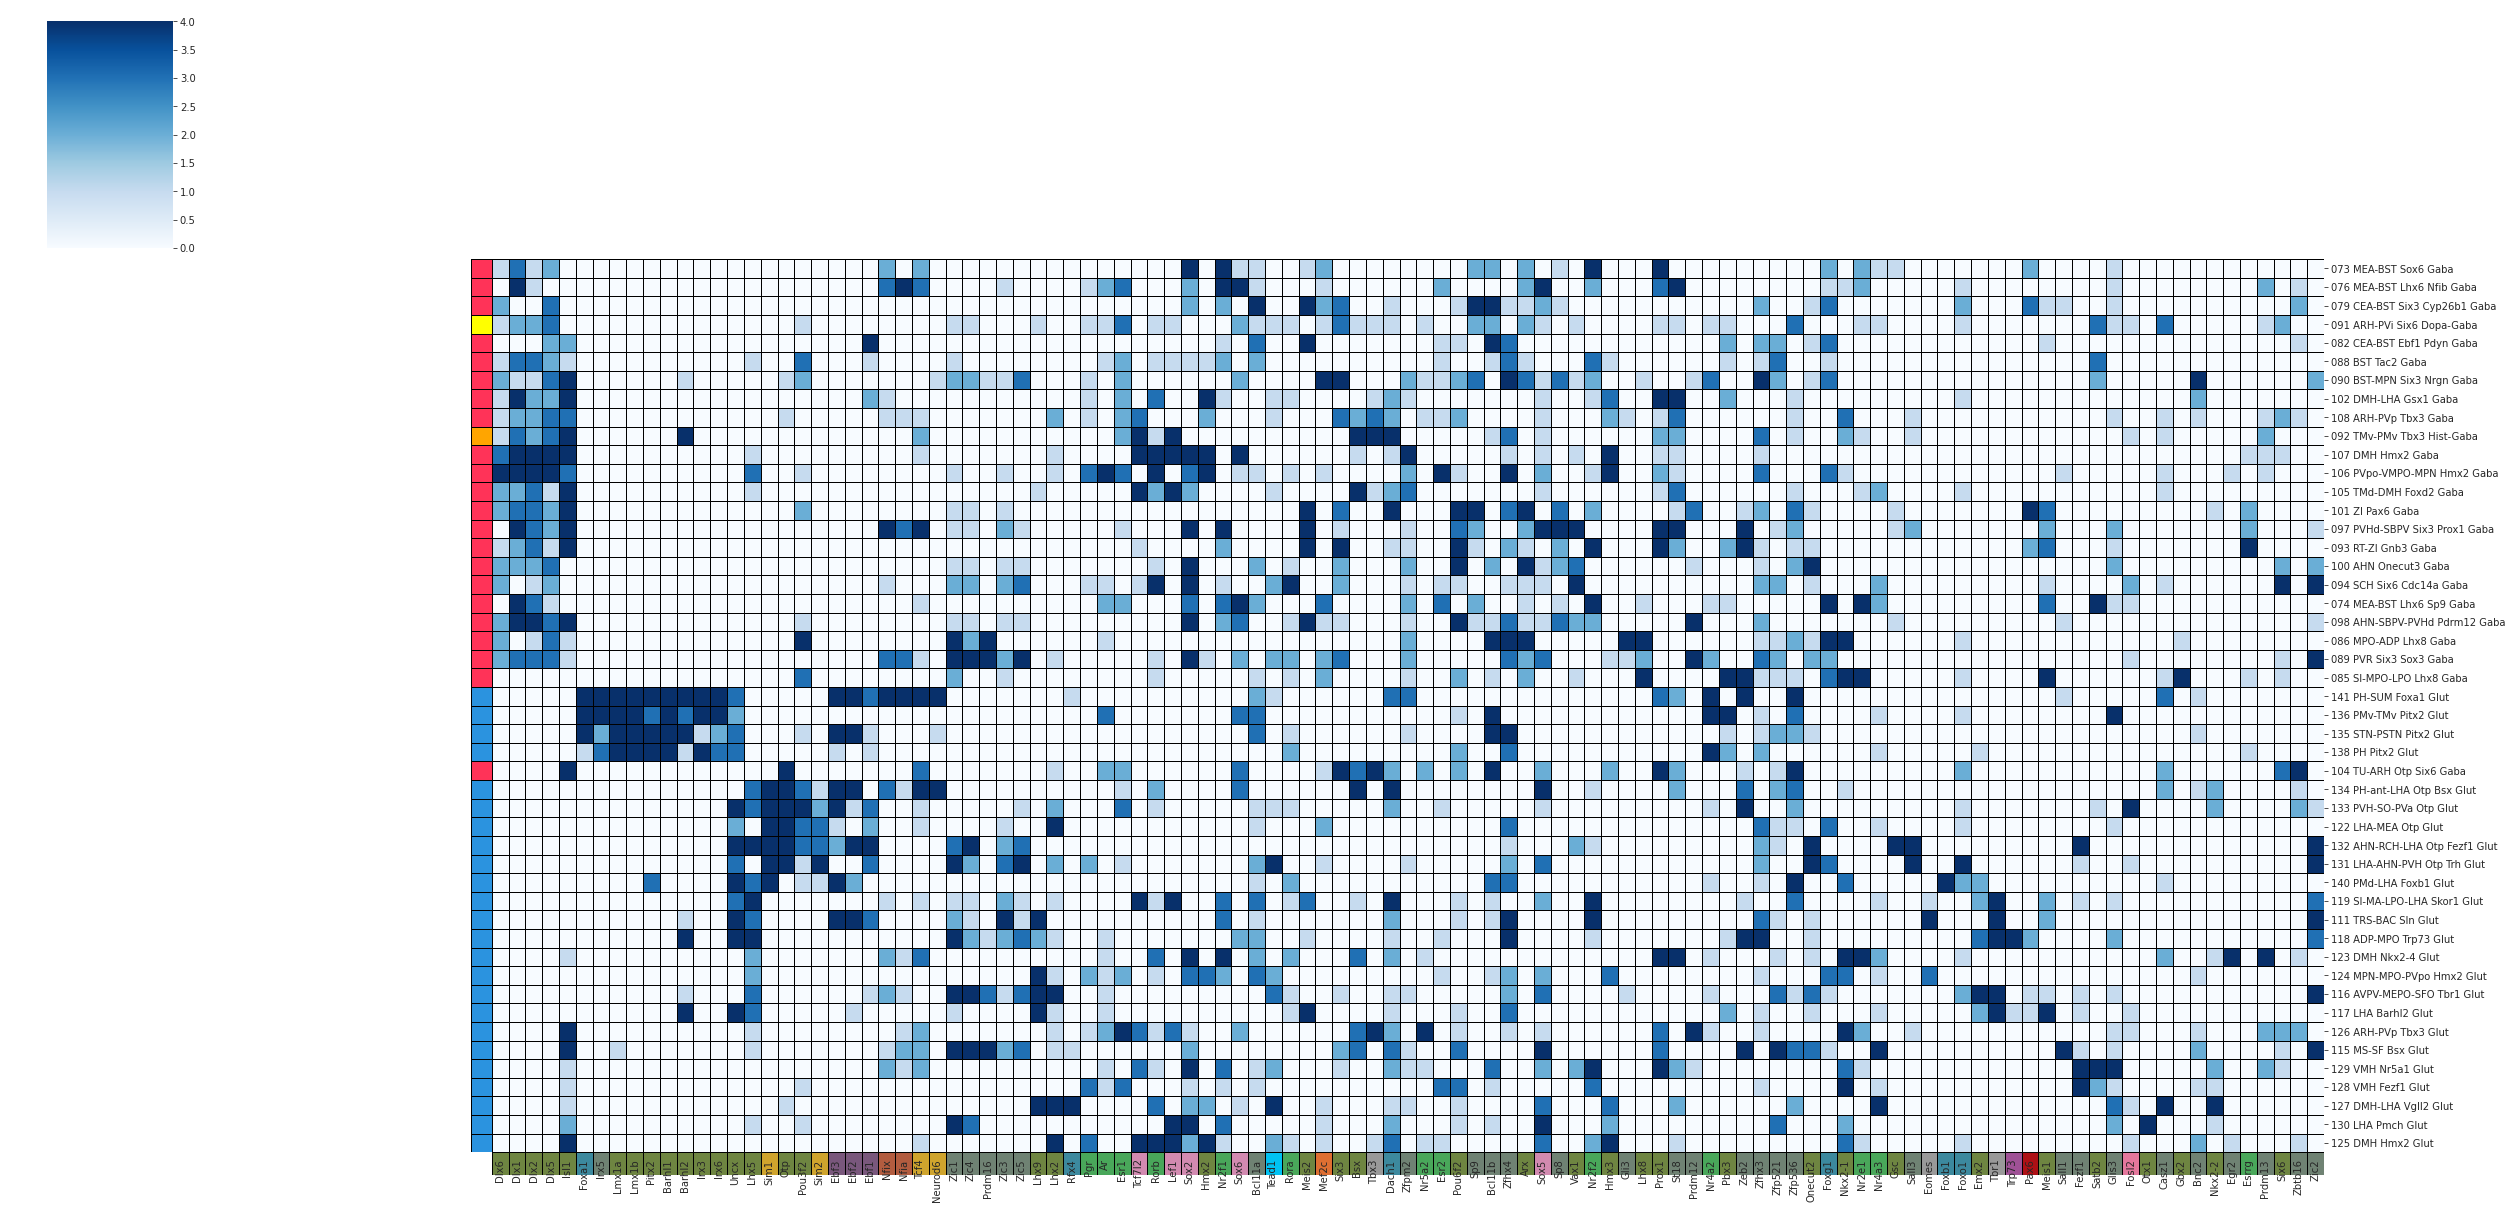

In [70]:
sns.set_style("white")
g = sns.clustermap(fbi_all, vmax = 4, vmin = 0,cmap = 'Blues', linewidths=1, linecolor = 'black',
               row_cluster = False, col_cluster = False,figsize = (1.4*25,1.4*12.5),
              col_colors = col_colors, row_colors = row_colors, colors_ratio = (.009,.02))

# Move col_colors to bottom
ax_col = g.ax_col_colors
ax_heatmap = g.ax_heatmap

# Get current positions
pos_col = ax_col.get_position()
pos_heat = ax_heatmap.get_position()

# Reposition col_colors below heatmap
# [x0, y0, width, height]
ax_col.set_position([pos_heat.x0,                    # Same x as heatmap
                     pos_heat.y0 - pos_col.height,  # Below heatmap with gap
                     pos_heat.width,                 # Same width as heatmap
                     pos_col.height])                # Keep original height

#remove x axis labels
#g.ax_heatmap.set_xticklabels([])
#g.ax_heatmap.set_xticks([])

#remove y axis labels
#g.ax_heatmap.set_yticklabels([])
#g.ax_heatmap.set_yticks([])

# Remove row_colors labels (y-axis)
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_xticklabels([])

# Remove col_colors labels (x-axis)
g.ax_col_colors.set_yticks([])
g.ax_col_colors.set_yticklabels([])

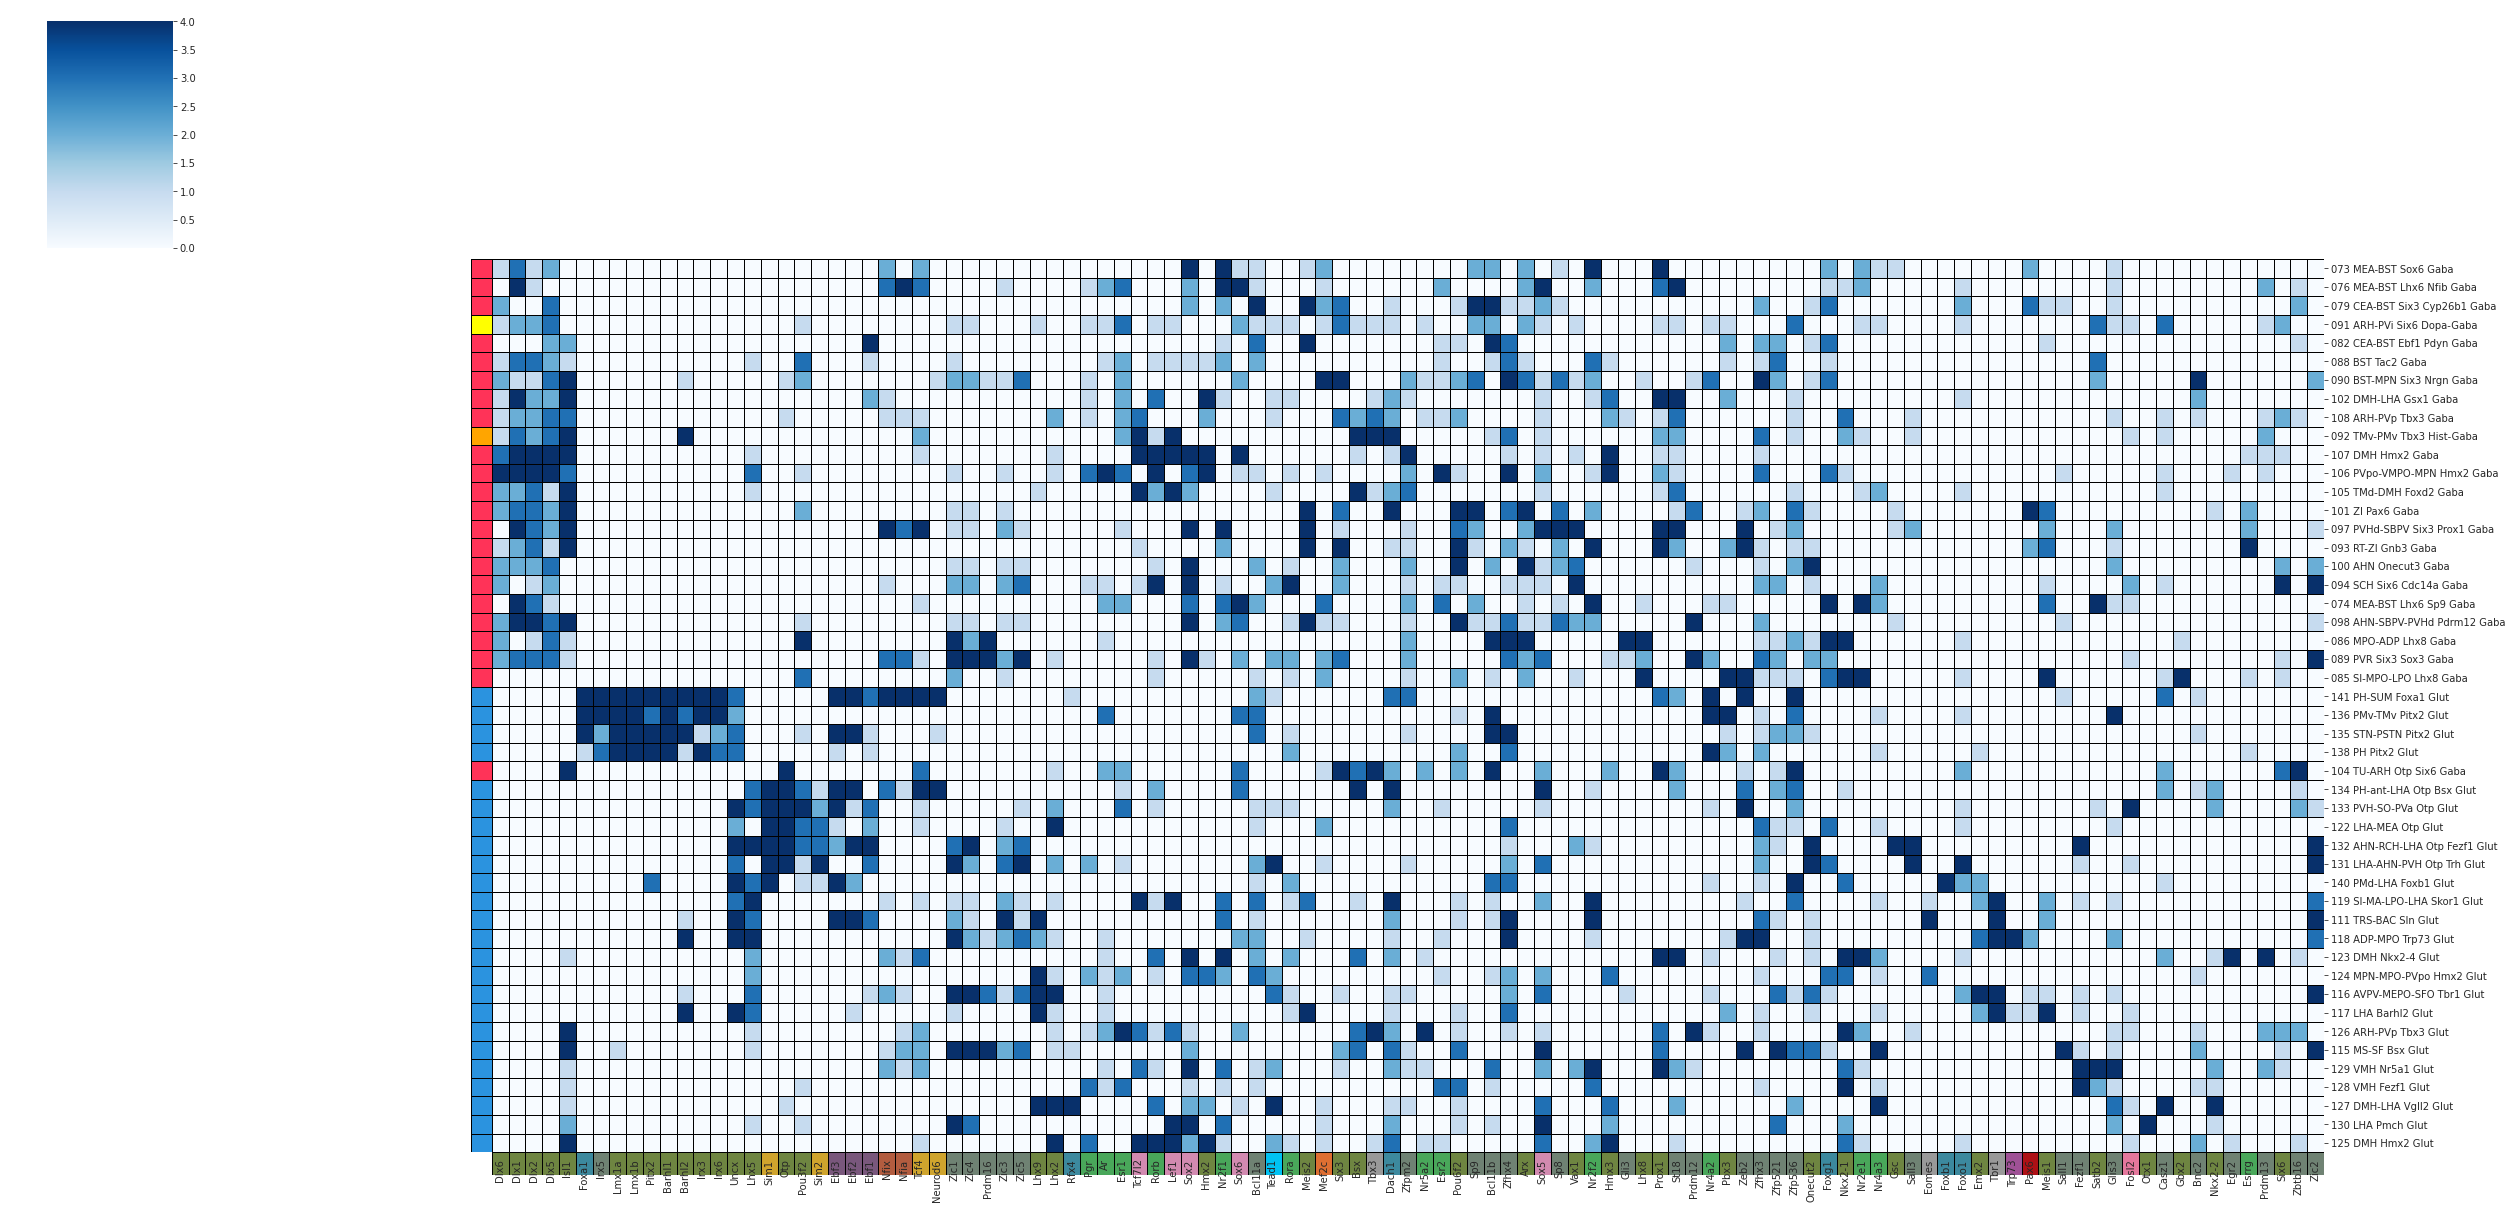

In [71]:
sns.set_style("white")
g = sns.clustermap(fbi_all, vmax = 4, vmin = 0,cmap = 'Blues', linewidths=1, linecolor = 'black',
               row_cluster = False, col_cluster = False,figsize = (1.4*25,1.4*12.5),
              col_colors = col_colors, row_colors = row_colors, colors_ratio = (.009,.02))

# Move col_colors to bottom
ax_col = g.ax_col_colors
ax_heatmap = g.ax_heatmap

# Get current positions
pos_col = ax_col.get_position()
pos_heat = ax_heatmap.get_position()

# Reposition col_colors below heatmap
# [x0, y0, width, height]
ax_col.set_position([pos_heat.x0,                    # Same x as heatmap
                     pos_heat.y0 - pos_col.height,  # Below heatmap with gap
                     pos_heat.width,                 # Same width as heatmap
                     pos_col.height])                # Keep original height

#remove x axis labels
#g.ax_heatmap.set_xticklabels([])
#g.ax_heatmap.set_xticks([])

#remove y axis labels
#g.ax_heatmap.set_yticklabels([])
#g.ax_heatmap.set_yticks([])

# Remove row_colors labels (y-axis)
g.ax_row_colors.set_xticks([])
g.ax_row_colors.set_xticklabels([])

# Remove col_colors labels (x-axis)
g.ax_col_colors.set_yticks([])
g.ax_col_colors.set_yticklabels([])
   
plt.savefig('../../Figures/Figures_08022026/TF_class_code_conservedct_sigdiff_08032026.svg',bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/TF_class_code_conservedct_sigdiff_08032026.png',dpi = 300)
plt.savefig('../../Figures/Figures_08022026/TF_class_code_conservedct_sigdiff_08032026.pdf',bbox_inches='tight')

In [72]:
fbi_all.to_csv('../../Figures/Figures_08022026/3A_TF_heatmap_sigdiff_08032026.csv')

In [73]:
plt_bar = JASPAR['Class'].value_counts().to_frame()
plt_bar['Conserved'] = [0 for i in range(len(plt_bar.index))]

In [74]:
for item in fbi_all.columns:
    if item != 'Pgr':
        if item.upper() in JASPAR.index:
            plt_bar.loc[JASPAR.loc[item.upper(),'Class'],'Conserved'] += 1
        elif item in JASPAR.index:
            plt_bar.loc[JASPAR.loc[item,'Class'],'Conserved'] += 1

In [75]:
np.sum(plt_bar['Conserved'])

108

In [76]:
plt_bar['Frac'] = plt_bar['Conserved']/plt_bar['Class']

In [77]:
plt_bar = plt_bar.sort_values('Conserved', ascending = True)

In [78]:
plt_bar_zeros = plt_bar[(plt_bar['Conserved'] > 0) & (plt_bar['Class'] > 5)]

In [79]:
plt_bar

,Class,Conserved,Frac
Tryptophan cluster factors; Homeo domain factors,7,0,0.000000
p53 domain factors,3,0,0.000000
Heat shock factors,3,0,0.000000
Heteromeric CCAAT-binding factors,3,0,0.000000
Grainyhead domain factors,4,0,0.000000
ARID,3,0,0.000000
Basic helix-loop-helix factors (bHLH); Basic helix-loop-helix factors (bHLH),5,0,0.000000
SMAD/NF-1 DNA-binding domain factors; Homeo domain factors,1,0,0.000000
Fork head/winged helix factors; Tryptophan cluster factors,5,0,0.000000
DM-type intertwined zinc finger factors,5,0,0.000000


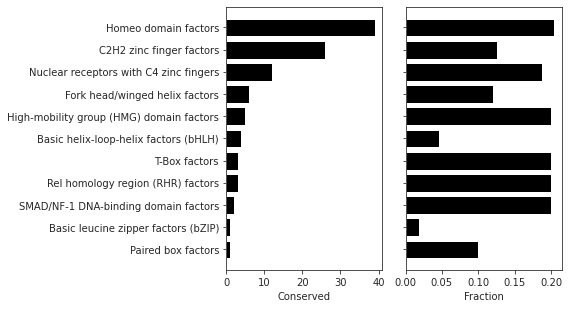

In [82]:
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.bottom'] = True

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8, len(plt_bar_zeros) * 0.4), sharey=True)

ax[0].barh(plt_bar_zeros.index, plt_bar_zeros['Conserved'], color='Black')
ax[1].barh(plt_bar_zeros.index, plt_bar_zeros['Frac'], color='Black')

ax[0].set_xlabel('Conserved')
ax[1].set_xlabel('Fraction')

for a in ax:
    a.tick_params(axis='x', which='both', length=4, width=0.8)
    a.spines['bottom'].set_visible(True)

for artist in fig.findobj():
    artist.set_clip_on(False)

plt.savefig('../../Figures/Figures_08022026/TF_class_sigdiff_08032026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/TF_class_sigdiff_08032026.png', dpi = 300, bbox_inches = 'tight')
plt.savefig('../../Figures/Figures_08022026/TF_class_sigdiff_08032026.pdf',bbox_inches='tight')
   
plt.tight_layout()
plt.show()

In [83]:
TF_mapping = pd.DataFrame(data = [list(fbi_all.columns),
                     [otohomo.loc[i,'MO'] for i in list(fbi_all.columns)],
                     [otohomo.loc[i,'CJ']for i in list(fbi_all.columns)],
                     [otohomo.loc[i,'AC'] for i in list(fbi_all.columns)],
                     [otohomo.loc[i,'XT'] for i in list(fbi_all.columns)],
                     [otohomo.loc[i,'DR'] for i in list(fbi_all.columns)],
                     c],
             index = ['Mouse TF name','Vole TF name','Quail TF name','Anole TF name','Xenopus TF name','Zebrafish TF name','TF class']).T

In [84]:
TF_mapping

,Mouse TF name,Vole TF name,Quail TF name,Anole TF name,Xenopus TF name,Zebrafish TF name,TF class
0,Dlx6,Dlx6,DLX6,dlx6,dlx6,dlx6a,Homeo domain factors
1,Dlx1,Dlx1,DLX1,dlx1,dlx1,dlx1a,Homeo domain factors
2,Dlx2,Dlx2,DLX2,dlx2,dlx2,dlx2a,Homeo domain factors
3,Dlx5,Dlx5,DLX5,dlx5,dlx5,dlx5a,Homeo domain factors
4,Isl1,Isl1,ISL1,isl1,isl1,isl1b_1,Homeo domain factors
...,...,...,...,...,...,...,...
104,Esrrg,Esrrg,ESRRG,esrrg,esrrg,esrrga,Nuclear receptors with C4 zinc fingers
105,Prdm13,Prdm13,PRDM13,prdm13,prdm13,prdm13,C2H2 zinc finger factors
106,Six6,Six6,SIX6,six6,six6,six6b,Homeo domain factors
107,Zbtb16,Zbtb16,ZBTB16,zbtb16,zbtb16,zbtb16b,C2H2 zinc finger factors


In [85]:
TF_mapping.to_csv('../../Figures/Figures_08022026/TF_mapping_allorgs_Fig3_08032026.csv')